# CUAD Contract Intelligence — Data Exploration & Cleaning


## 1. Environment Sanity Check

In [1]:
import sys
print("Python executable:", sys.executable)
print("Python version   :", sys.version)


Python executable: c:\Users\ATHARVA\OneDrive\Desktop\git\contract-intelligence\venv\Scripts\python.exe
Python version   : 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


## 2. Install Dependencies

In [2]:
import sys

packages = [
    "datasets",
    "transformers",
    "spacy",
    "torch",
    "pandas",
    "numpy",
    "scikit-learn",
]

import subprocess
subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet"] + packages,
    check=True
)
print("✅ All packages installed / verified.")

✅ All packages installed / verified.


## 3. Import Libraries

In [3]:
import os
import re
import ast
import zipfile
import urllib.request

import pandas as pd
import numpy as np

print("✅ Libraries imported.")

✅ Libraries imported.


## 4. Download & Extract CUAD v1 Dataset
> Skip this cell if you already have the data locally.

In [4]:
DATA_DIR = "../data/raw"
ZIP_PATH = os.path.join(DATA_DIR, "CUAD_v1.zip")
URL      = "https://zenodo.org/record/4595826/files/CUAD_v1.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    print("Downloading CUAD_v1.zip ...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("Download complete.")
else:
    print("Zip already exists — skipping download.")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(DATA_DIR)

print("✅ Extracted. Contents:", os.listdir(DATA_DIR))


Zip already exists — skipping download.
✅ Extracted. Contents: ['CUAD_v1', 'CUAD_v1.zip']


## 5. List All Extracted Files

In [5]:
for root, dirs, files in os.walk("../data/raw"):
    for file in files:
        print(os.path.join(root, file))

../data/raw\CUAD_v1.zip
../data/raw\CUAD_v1\CUAD_v1.json
../data/raw\CUAD_v1\CUAD_v1_README.txt
../data/raw\CUAD_v1\master_clauses.csv
../data/raw\CUAD_v1\master_clauses_cleaned.csv
../data/raw\CUAD_v1\master_clauses_final.csv
../data/raw\CUAD_v1\full_contract_pdf\Part_I\Affiliate_Agreements\CreditcardscomInc_20070810_S-1_EX-10.33_362297_EX-10.33_Affiliate Agreement.pdf
../data/raw\CUAD_v1\full_contract_pdf\Part_I\Affiliate_Agreements\CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf
../data/raw\CUAD_v1\full_contract_pdf\Part_I\Affiliate_Agreements\DigitalCinemaDestinationsCorp_20111220_S-1_EX-10.10_7346719_EX-10.10_Affiliate Agreement.pdf
../data/raw\CUAD_v1\full_contract_pdf\Part_I\Affiliate_Agreements\LinkPlusCorp_20050802_8-K_EX-10_3240252_EX-10_Affiliate Agreement.pdf
../data/raw\CUAD_v1\full_contract_pdf\Part_I\Affiliate_Agreements\SouthernStarEnergyInc_20051202_SB-2A_EX-9_801890_EX-9_Affiliate Agreement.pdf
../data/raw\CUAD_v1\full_contract_pdf\P

## 6. Define File Paths

In [6]:
CSV_INPUT  = "../data/raw/CUAD_v1/master_clauses.csv"
CSV_OUTPUT = "../data/raw/CUAD_v1/master_clauses_final.csv"

print("Input  :", CSV_INPUT)
print("Output :", CSV_OUTPUT)


Input  : ../data/raw/CUAD_v1/master_clauses.csv
Output : ../data/raw/CUAD_v1/master_clauses_final.csv


## 7. Load the Dataset

In [7]:
data = pd.read_csv(CSV_INPUT, encoding="utf-8-sig")

print(f"Shape  : {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head(3)


Shape  : (510, 83)
Columns: ['Filename', 'Document Name', 'Document Name-Answer', 'Parties', 'Parties-Answer', 'Agreement Date', 'Agreement Date-Answer', 'Effective Date', 'Effective Date-Answer', 'Expiration Date', 'Expiration Date-Answer', 'Renewal Term', 'Renewal Term-Answer', 'Notice Period To Terminate Renewal', 'Notice Period To Terminate Renewal- Answer', 'Governing Law', 'Governing Law-Answer', 'Most Favored Nation', 'Most Favored Nation-Answer', 'Competitive Restriction Exception', 'Competitive Restriction Exception-Answer', 'Non-Compete', 'Non-Compete-Answer', 'Exclusivity', 'Exclusivity-Answer', 'No-Solicit Of Customers', 'No-Solicit Of Customers-Answer', 'No-Solicit Of Employees', 'No-Solicit Of Employees-Answer', 'Non-Disparagement', 'Non-Disparagement-Answer', 'Termination For Convenience', 'Termination For Convenience-Answer', 'Rofr/Rofo/Rofn', 'Rofr/Rofo/Rofn-Answer', 'Change Of Control', 'Change Of Control-Answer', 'Anti-Assignment', 'Anti-Assignment-Answer', 'Revenue/

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No


## 8. Exploratory Data Analysis
### 8a — Basic Statistic

In [8]:
print("Shape  :", data.shape)
print("\nNull counts per column:")
print(data.isnull().sum())


Shape  : (510, 83)

Null counts per column:
Filename                          0
Document Name                     0
Document Name-Answer              0
Parties                           0
Parties-Answer                    1
                                 ..
Insurance-Answer                  0
Covenant Not To Sue               0
Covenant Not To Sue-Answer        0
Third Party Beneficiary           0
Third Party Beneficiary-Answer    0
Length: 83, dtype: int64


### 8b — Unique Values per Column

In [9]:
data.nunique()

Filename                          510
Document Name                     274
Document Name-Answer              285
Parties                           502
Parties-Answer                    499
                                 ... 
Insurance-Answer                    2
Covenant Not To Sue               101
Covenant Not To Sue-Answer          2
Third Party Beneficiary            33
Third Party Beneficiary-Answer      2
Length: 83, dtype: int64

### 8c — Data Types

In [10]:
data.dtypes

Filename                          str
Document Name                     str
Document Name-Answer              str
Parties                           str
Parties-Answer                    str
                                 ... 
Insurance-Answer                  str
Covenant Not To Sue               str
Covenant Not To Sue-Answer        str
Third Party Beneficiary           str
Third Party Beneficiary-Answer    str
Length: 83, dtype: object

### 8d — Sample Rows

In [11]:
data.head(5)

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


In [12]:
data.head(5)

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


## 9. Create Working Copy

In [13]:
df = data.copy()
print("Working copy created. Shape:", df.shape)
data.head()

Working copy created. Shape: (510, 83)


,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


## 10. Define Cell Cleaning Function

In [14]:
def clean_cell(value):
    """
    Cleans a single cell value:
    - Returns empty string for nulls
    - Flattens list-like strings into plain text
    - Strips brackets, quotes, tabs, newlines
    - Collapses multiple spaces
    - Removes spaces before punctuation
    """
    # Handle nulls
    if pd.isna(value):
        return ""

    value = str(value).strip()

    # Handle empty list strings
    if value in ["[]", "['']", '[""]']:
        return ""

    # Handle list-like strings e.g. "['item1', 'item2']"
    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                cleaned_items = [
                    str(item).strip()
                    for item in parsed
                    if item is not None and str(item).strip()
                ]
                value = " ".join(cleaned_items)
        except (ValueError, SyntaxError):
            value = value.strip("[]")

    # Strip brackets, quotes
    value = value.replace("[", "").replace("]", "")
    value = value.replace('"', "").replace("'", "")

    # Remove tabs and newlines
    value = re.sub(r"[\r\n\t]+", " ", value)

    # Collapse multiple spaces
    value = re.sub(r"\s+", " ", value)

    # Remove spaces before punctuation
    value = re.sub(r"\s+([,.!?;:])", r"\1", value)

    return value.strip()

print("✅ clean_cell() function defined.")


✅ clean_cell() function defined.


## 11. Apply Cleaning to All Columns

In [15]:
for col in df.columns:
    df[col] = df[col].apply(clean_cell)

print(f"✅ Cleaned all {len(df.columns)} columns.")
df.head(3)

✅ Cleaned all 83 columns.


,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,MARKETING AFFILIATE AGREEMENT,MARKETING AFFILIATE AGREEMENT,BIRCH FIRST GLOBAL INVESTMENTS INC. MA Marketi...,Birch First Global Investments Inc. (Company);...,"8th day of May 2014 May 8, 2014",5/8/14,This agreement shall begin upon the date of it...,,This agreement shall begin upon the date of it...,...,,No,COMPANYS SOLE AND EXCLUSIVE LIABILITY FOR THE ...,Yes,,No,,No,,No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,EuroMedia Holdings Corp. Rogers Rogers Cable C...,Rogers Cable Communications Inc. (Rogers); Eur...,"July 11, 2006",7/11/06,"July 11, 2006",7/11/06,The term of this Agreement (the Initial Term) ...,...,,No,,No,,No,,No,,No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,CONTENT DISTRIBUTION AND LICENSE AGREEMENT,CONTENT DISTRIBUTION AND LICENSE AGREEMENT,Producer Fulucai Productions Ltd. ConvergTV CO...,"CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","November 15, 2012",11/15/12,"November 15, 2012",11/15/12,,...,,No,,No,,No,,No,,No


In [16]:
def is_valid_date(val):
    if pd.isna(val) or str(val).strip() == "":
        return False
    
    val = str(val).strip()
    
    # Remove if it's ONLY symbols, blanks, commas, dots
    if re.fullmatch(r'[_\-•·●,\.\s\*]+', val):
        return False
    
    # Remove if it has 2+ consecutive underscores (unfilled blank)
    if re.search(r'_{2,}', val):
        return False
    
    # Remove if it has no actual month name or numeric date
    # Must contain either a month name OR a valid number pattern
    has_month  = bool(re.search(
        r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\w*\b',
        val, re.IGNORECASE
    ))
    has_number = bool(re.search(r'\d{1,2}[\-\/]\d{1,2}', val))  # e.g. 03/24
    has_year   = bool(re.search(r'\b(19|20)\d{2}\b', val))       # e.g. 2015

    # Must have at least a month + year OR numeric date
    if not ((has_month and has_year) or has_number):
        return False
    
    return True

# ── Apply to Agreement Date-Answer column ─────────────────
col = "Agreement Date-Answer"

before = df[col].notna().sum()
df[col] = df[col].apply(lambda x: x if is_valid_date(x) else "")
after  = (df[col] != "").sum()

print(f"'{col}'")
print(f"  Before: {before} non-empty values")
print(f"  After : {after} valid dates")
print(f"  Removed: {before - after} blank/template entries")

'Agreement Date-Answer'
  Before: 510 non-empty values
  After : 420 valid dates
  Removed: 90 blank/template entries


## 12. Drop Fully Empty Columns & Rows

In [17]:
# Replace blank strings with NA for accurate detection
df = df.replace("", pd.NA)

# Drop columns where ALL values are empty
before = df.shape
df = df.dropna(axis=1, how="all")
print(f"Columns: {before[1]} → {df.shape[1]}  (removed {before[1] - df.shape[1]} empty columns)")

# Drop rows where ALL values are empty
df = df.dropna(axis=0, how="all")
print(f"Rows   : {before[0]} → {df.shape[0]}  (removed {before[0] - df.shape[0]} empty rows)")

# Fill remaining NAs with empty string
df = df.fillna("")

print(f"\n✅ Final shape: {df.shape}")


Columns: 83 → 83  (removed 0 empty columns)
Rows   : 510 → 510  (removed 0 empty rows)

✅ Final shape: (510, 83)


## 13. Drop Duplicate Rows

In [18]:
before = len(df)
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"Rows before: {before} | After: {len(df)} | Removed: {before - len(df)} duplicates")


Rows before: 510 | After: 510 | Removed: 0 duplicates


## 14. Reorder Columns
Put identification columns first, then each clause paired with its Answer column.

In [19]:
columns  = list(df.columns)
new_order = []

# Step 1: Identification columns first
for col in ["Filename", "Document Name"]:
    if col in columns:
        new_order.append(col)

# Step 2: Pair each clause column with its -Answer column
for col in columns:
    if col in new_order:
        continue
    if str(col).lower().endswith("-answer"):
        continue  # skip; will be added after its parent

    new_order.append(col)
    answer_col = col + "-Answer"
    if answer_col in columns:
        new_order.append(answer_col)

# Step 3: Add anything remaining not yet in new_order
for col in columns:
    if col not in new_order:
        new_order.append(col)

df = df[new_order]
print(f"✅ Columns reordered. Final column count: {len(df.columns)}")
print(df.columns.tolist())


✅ Columns reordered. Final column count: 83
['Filename', 'Document Name', 'Parties', 'Parties-Answer', 'Agreement Date', 'Agreement Date-Answer', 'Effective Date', 'Effective Date-Answer', 'Expiration Date', 'Expiration Date-Answer', 'Renewal Term', 'Renewal Term-Answer', 'Notice Period To Terminate Renewal', 'Notice Period To Terminate Renewal- Answer', 'Governing Law', 'Governing Law-Answer', 'Most Favored Nation', 'Most Favored Nation-Answer', 'Competitive Restriction Exception', 'Competitive Restriction Exception-Answer', 'Non-Compete', 'Non-Compete-Answer', 'Exclusivity', 'Exclusivity-Answer', 'No-Solicit Of Customers', 'No-Solicit Of Customers-Answer', 'No-Solicit Of Employees', 'No-Solicit Of Employees-Answer', 'Non-Disparagement', 'Non-Disparagement-Answer', 'Termination For Convenience', 'Termination For Convenience-Answer', 'Rofr/Rofo/Rofn', 'Rofr/Rofo/Rofn-Answer', 'Change Of Control', 'Change Of Control-Answer', 'Anti-Assignment', 'Anti-Assignment-Answer', 'Revenue/Profit S

## 15. Final Row Filter
Remove any rows that are completely empty across all columns.

In [20]:
before = len(df)

df = df[
    df.apply(
        lambda row: any(str(x).strip() != "" for x in row),
        axis=1
    )
]

df = df.reset_index(drop=True)
print(f"Rows before: {before} | After: {len(df)} | Removed: {before - len(df)}")


Rows before: 510 | After: 510 | Removed: 0


## 16. Final Preview

In [21]:
print("Final shape:", df.shape)
print("\nSample data:")
df.head(5)


Final shape: (510, 83)

Sample data:


,Filename,Document Name,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,Expiration Date-Answer,...,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer,Document Name-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,MARKETING AFFILIATE AGREEMENT,BIRCH FIRST GLOBAL INVESTMENTS INC. MA Marketi...,Birch First Global Investments Inc. (Company);...,"8th day of May 2014 May 8, 2014",5/8/14,This agreement shall begin upon the date of it...,,This agreement shall begin upon the date of it...,12/31/14,...,No,COMPANYS SOLE AND EXCLUSIVE LIABILITY FOR THE ...,Yes,,No,,No,,No,MARKETING AFFILIATE AGREEMENT
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,EuroMedia Holdings Corp. Rogers Rogers Cable C...,Rogers Cable Communications Inc. (Rogers); Eur...,"July 11, 2006",7/11/06,"July 11, 2006",7/11/06,The term of this Agreement (the Initial Term) ...,6/30/10,...,No,,No,,No,,No,,No,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,CONTENT DISTRIBUTION AND LICENSE AGREEMENT,Producer Fulucai Productions Ltd. ConvergTV CO...,"CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","November 15, 2012",11/15/12,"November 15, 2012",11/15/12,,,...,No,,No,,No,,No,,No,CONTENT DISTRIBUTION AND LICENSE AGREEMENT
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,WEBSITE CONTENT LICENSE AGREEMENT,PSiTech Corporation Licensor Licensee Empirica...,PSiTech Corporation (Licensor); Empirical Vent...,"Feb 10, 2014",2/10/14,"Feb 10, 2014",2/10/14,The initial term of this Agreement commences a...,2/10/19,...,No,,No,,No,,No,,No,WEBSITE CONTENT LICENSE AGREEMENT
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,CONTENT LICENSE AGREEMENT,"YOU ON DEMAND HOLDINGS, INC. Licensor Licensee...",Beijing Sun Seven Stars Culture Development Li...,"December 21, 2015",12/21/15,"December 21, 2015",12/21/15,The Term of this Agreement (the Term) shall co...,12/21/35,...,No,,No,,No,,No,,No,CONTENT LICENSE AGREEMENT


## 17. Save Cleaned File

In [22]:
import tempfile

# Try project output path first, fall back to temp dir
try:
    output_path = CSV_OUTPUT
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
except PermissionError:
    output_path = os.path.join(tempfile.gettempdir(), "master_clauses_final.csv")
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print("⚠️  Permission denied on project path — saved to temp folder instead.")

print(f"✅ File saved successfully!")
print(f"   Path  : {output_path}")
print(f"   Shape : {df.shape}")


✅ File saved successfully!
   Path  : ../data/raw/CUAD_v1/master_clauses_final.csv
   Shape : (510, 83)


## 18. Dataset Structure Analysis

Before model training, inspect the cleaned CUAD structure and identify the clause and answer columns.

This step converts the cleaned contract data into a form that can later be used for ML training.

In [23]:
# Inspect columns and basic structure
print("Number of rows:", len(df))
print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
display(df.dtypes)

Number of rows: 510

Columns:
1. Filename
2. Document Name
3. Parties
4. Parties-Answer
5. Agreement Date
6. Agreement Date-Answer
7. Effective Date
8. Effective Date-Answer
9. Expiration Date
10. Expiration Date-Answer
11. Renewal Term
12. Renewal Term-Answer
13. Notice Period To Terminate Renewal
14. Notice Period To Terminate Renewal- Answer
15. Governing Law
16. Governing Law-Answer
17. Most Favored Nation
18. Most Favored Nation-Answer
19. Competitive Restriction Exception
20. Competitive Restriction Exception-Answer
21. Non-Compete
22. Non-Compete-Answer
23. Exclusivity
24. Exclusivity-Answer
25. No-Solicit Of Customers
26. No-Solicit Of Customers-Answer
27. No-Solicit Of Employees
28. No-Solicit Of Employees-Answer
29. Non-Disparagement
30. Non-Disparagement-Answer
31. Termination For Convenience
32. Termination For Convenience-Answer
33. Rofr/Rofo/Rofn
34. Rofr/Rofo/Rofn-Answer
35. Change Of Control
36. Change Of Control-Answer
37. Anti-Assignment
38. Anti-Assignment-Answer
39.

Filename                          str
Document Name                     str
Parties                           str
Parties-Answer                    str
Agreement Date                    str
                                 ... 
Covenant Not To Sue               str
Covenant Not To Sue-Answer        str
Third Party Beneficiary           str
Third Party Beneficiary-Answer    str
Document Name-Answer              str
Length: 83, dtype: object

In [24]:
# Identify CUAD clause/category columns and their corresponding answer columns
answer_columns = [c for c in df.columns if c.lower().endswith("-answer")]

metadata_columns = {
    "id", "title", "context", "text", "contract", "document",
    "filename", "file name", "document name"
}

clause_columns = [
    c for c in df.columns
    if c not in answer_columns and c.lower() not in metadata_columns
]

print("Number of clause/category columns:", len(clause_columns))
print("Number of answer columns:", len(answer_columns))
print("\nClause/category columns:")
print(clause_columns)
print("\nAnswer columns:")
print(answer_columns)

assert len(clause_columns) > 0, "No clause/category columns detected."
assert len(answer_columns) > 0, "No CUAD -Answer columns detected."


Number of clause/category columns: 41
Number of answer columns: 40

Clause/category columns:
['Parties', 'Agreement Date', 'Effective Date', 'Expiration Date', 'Renewal Term', 'Notice Period To Terminate Renewal', 'Notice Period To Terminate Renewal- Answer', 'Governing Law', 'Most Favored Nation', 'Competitive Restriction Exception', 'Non-Compete', 'Exclusivity', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Non-Disparagement', 'Termination For Convenience', 'Rofr/Rofo/Rofn', 'Change Of Control', 'Anti-Assignment', 'Revenue/Profit Sharing', 'Price Restrictions', 'Minimum Commitment', 'Volume Restriction', 'Ip Ownership Assignment', 'Joint Ip Ownership', 'License Grant', 'Non-Transferable License', 'Affiliate License-Licensor', 'Affiliate License-Licensee', 'Unlimited/All-You-Can-Eat-License', 'Irrevocable Or Perpetual License', 'Source Code Escrow', 'Post-Termination Services', 'Audit Rights', 'Uncapped Liability', 'Cap On Liability', 'Liquidated Damages', 'Warranty Duration'

## 19. Convert CUAD → ML Training Examples

CUAD is stored in a wide format with clause/answer pairs. For model training, convert it into a long format containing:

- `text` — clause text
- `label` — clause category
- `answer` — annotated answer, when available

Only non-empty clause examples are retained.

In [25]:
# Identify CUAD category columns and their corresponding answer columns

answer_columns = [
    c for c in df.columns
    if c.lower().endswith("-answer")
]

clause_columns = [
    c for c in df.columns
    if c not in answer_columns
]

# Remove non-category columns if they exist
metadata_columns = [
    "id",
    "title",
    "context",
    "text",
    "contract",
    "document",
    "filename"
]

clause_columns = [
    c for c in clause_columns
    if c.lower() not in metadata_columns
]

print("Number of clause/category columns:", len(clause_columns))
print("\nClause/category columns:")
print(clause_columns)

print("\nNumber of answer columns:", len(answer_columns))
print("\nAnswer columns:")
print(answer_columns)

Number of clause/category columns: 42

Clause/category columns:
['Document Name', 'Parties', 'Agreement Date', 'Effective Date', 'Expiration Date', 'Renewal Term', 'Notice Period To Terminate Renewal', 'Notice Period To Terminate Renewal- Answer', 'Governing Law', 'Most Favored Nation', 'Competitive Restriction Exception', 'Non-Compete', 'Exclusivity', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Non-Disparagement', 'Termination For Convenience', 'Rofr/Rofo/Rofn', 'Change Of Control', 'Anti-Assignment', 'Revenue/Profit Sharing', 'Price Restrictions', 'Minimum Commitment', 'Volume Restriction', 'Ip Ownership Assignment', 'Joint Ip Ownership', 'License Grant', 'Non-Transferable License', 'Affiliate License-Licensor', 'Affiliate License-Licensee', 'Unlimited/All-You-Can-Eat-License', 'Irrevocable Or Perpetual License', 'Source Code Escrow', 'Post-Termination Services', 'Audit Rights', 'Uncapped Liability', 'Cap On Liability', 'Liquidated Damages', 'Warranty Duration', 'Insurance

In [26]:
# Build a long-format ML dataset from CUAD category/answer pairs

training_rows = []

for clause_col in clause_columns:
    answer_col = f"{clause_col}-Answer"
    if answer_col not in df.columns:
        continue

    for _, row in df.iterrows():
        answer = row[answer_col]

        if pd.isna(answer):
            continue

        answer = str(answer).strip()
        if not answer:
            continue

        training_rows.append({
            "text": answer,
            "label": clause_col,
            "answer": answer
        })

ml_df = pd.DataFrame(training_rows, columns=["text", "label", "answer"])

print("ML dataset shape:", ml_df.shape)
print("Number of labels:", ml_df["label"].nunique())
display(ml_df.head())

assert not ml_df.empty, "ERROR: No training rows were created."
assert "label" in ml_df.columns, "ERROR: label column was not created."


ML dataset shape: (19553, 3)
Number of labels: 40


,text,label,answer
0,MARKETING AFFILIATE AGREEMENT,Document Name,MARKETING AFFILIATE AGREEMENT
1,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,Document Name,VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT
2,CONTENT DISTRIBUTION AND LICENSE AGREEMENT,Document Name,CONTENT DISTRIBUTION AND LICENSE AGREEMENT
3,WEBSITE CONTENT LICENSE AGREEMENT,Document Name,WEBSITE CONTENT LICENSE AGREEMENT
4,CONTENT LICENSE AGREEMENT,Document Name,CONTENT LICENSE AGREEMENT


## 20. Clause Label Distribution

Check class distribution before training. CUAD contains multiple legal clause categories, so class imbalance needs to be understood before selecting and training the model.

In [27]:
# Clause/category distribution
label_counts = ml_df["label"].value_counts()

display(label_counts.to_frame("count"))

print("Number of clause categories:", ml_df["label"].nunique())

,count
label,
Document Name,510
Most Favored Nation,510
Competitive Restriction Exception,510
Non-Compete,510
Exclusivity,510
No-Solicit Of Customers,510
No-Solicit Of Employees,510
Non-Disparagement,510
Termination For Convenience,510


Number of clause categories: 40


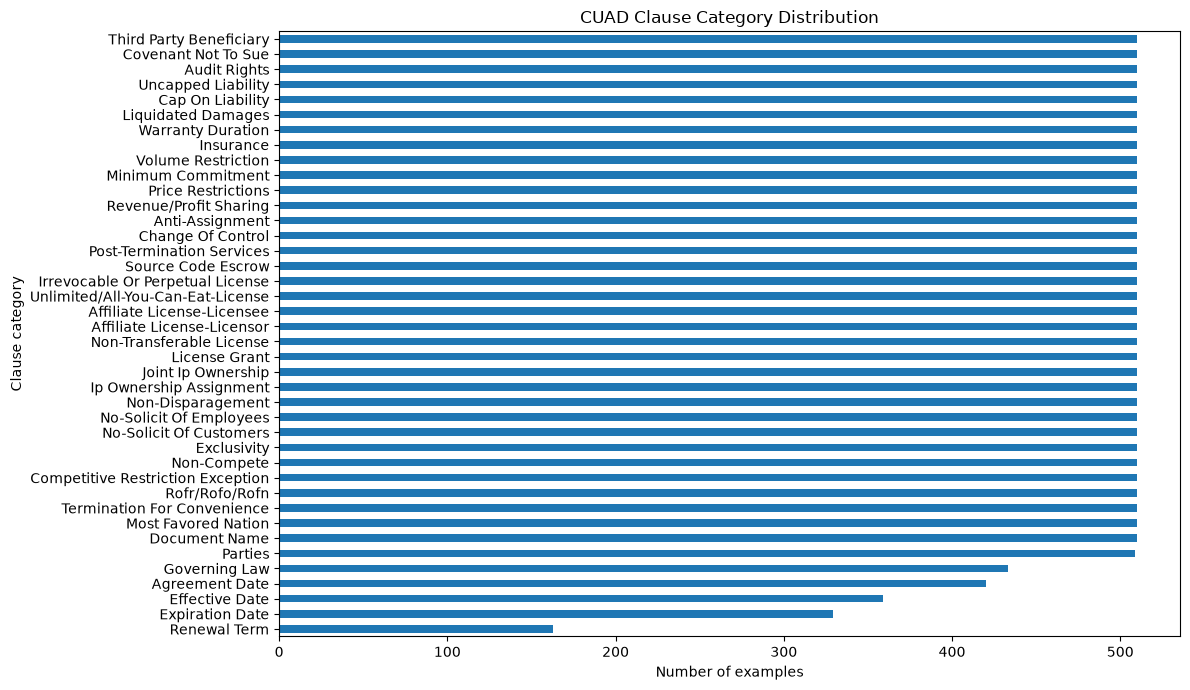

In [28]:
# Visualize the clause distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
label_counts.sort_values().plot(kind="barh")
plt.xlabel("Number of examples")
plt.ylabel("Clause category")
plt.title("CUAD Clause Category Distribution")
plt.tight_layout()
plt.show()

## 21. Train / Validation / Test Split

Create separate datasets for training, validation, and final testing.

A stratified split is used so that clause categories are represented as consistently as possible across the splits.

In [29]:
from sklearn.model_selection import train_test_split

# Remove rows with missing labels/text
ml_df = ml_df.dropna(subset=["text", "label"]).copy()
ml_df["text"] = ml_df["text"].astype(str).str.strip()

# Remove empty text
ml_df = ml_df[ml_df["text"] != ""].reset_index(drop=True)

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    ml_df,
    test_size=0.30,
    random_state=42,
    stratify=ml_df["label"]
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (13687, 3)
Validation: (2933, 3)
Test: (2933, 3)


In [30]:
# Verify label distribution across splits
print("Train label distribution:")
display(train_df["label"].value_counts(normalize=True).head(15))

print("Validation label distribution:")
display(val_df["label"].value_counts(normalize=True).head(15))

print("Test label distribution:")
display(test_df["label"].value_counts(normalize=True).head(15))

Train label distribution:


label
No-Solicit Of Employees              0.026083
Anti-Assignment                      0.026083
Source Code Escrow                   0.026083
Change Of Control                    0.026083
Competitive Restriction Exception    0.026083
Warranty Duration                    0.026083
Non-Transferable License             0.026083
No-Solicit Of Customers              0.026083
Non-Compete                          0.026083
Insurance                            0.026083
Document Name                        0.026083
Uncapped Liability                   0.026083
Post-Termination Services            0.026083
Termination For Convenience          0.026083
Liquidated Damages                   0.026083
Name: proportion, dtype: float64

Validation label distribution:


label
Non-Disparagement                   0.026253
Minimum Commitment                  0.026253
Document Name                       0.026253
Source Code Escrow                  0.026253
Most Favored Nation                 0.026253
Change Of Control                   0.026253
No-Solicit Of Employees             0.026253
Irrevocable Or Perpetual License    0.026253
Joint Ip Ownership                  0.026253
Volume Restriction                  0.026253
Affiliate License-Licensee          0.026253
Third Party Beneficiary             0.026253
Exclusivity                         0.026253
Termination For Convenience         0.026253
Warranty Duration                   0.026253
Name: proportion, dtype: float64

Test label distribution:


label
Covenant Not To Sue                  0.026253
Competitive Restriction Exception    0.026253
Price Restrictions                   0.026253
Affiliate License-Licensor           0.026253
Anti-Assignment                      0.026253
Ip Ownership Assignment              0.026253
No-Solicit Of Customers              0.026253
Non-Transferable License             0.026253
Audit Rights                         0.026253
License Grant                        0.026253
Unlimited/All-You-Can-Eat-License    0.026253
Post-Termination Services            0.026253
Revenue/Profit Sharing               0.026253
Non-Compete                          0.026253
Insurance                            0.026253
Name: proportion, dtype: float64

## 22. Export Training-Ready JSONL Files

Create the Week-1 training/validation/test artifacts used by the Week-2 transformer notebook.

In [31]:
from pathlib import Path
import json

ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def export_jsonl(frame, path):
    records = frame[["text", "label", "answer"]].to_dict(orient="records")
    with open(path, "w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    return len(records)

n_train = export_jsonl(train_df, ARTIFACT_DIR / "train.jsonl")
n_val = export_jsonl(val_df, ARTIFACT_DIR / "validation.jsonl")
n_test = export_jsonl(test_df, ARTIFACT_DIR / "test.jsonl")

print("Exported:")
print(" train.jsonl     :", n_train)
print(" validation.jsonl:", n_val)
print(" test.jsonl      :", n_test)


Exported:
 train.jsonl     : 13687
 validation.jsonl: 2933
 test.jsonl      : 2933


## 23. Validate JSONL Artifacts

In [32]:
def validate_jsonl(path):
    path = Path(path)
    assert path.exists(), f"Missing file: {path}"
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            if not line.strip():
                continue
            obj = json.loads(line)
            assert isinstance(obj.get("text"), str) and obj["text"].strip()
            assert isinstance(obj.get("label"), str) and obj["label"].strip()
            rows.append(obj)
    assert rows, f"No records found in {path}"
    return rows

for name in ["train.jsonl", "validation.jsonl", "test.jsonl"]:
    rows = validate_jsonl(ARTIFACT_DIR / name)
    print(f"✓ {name}: {len(rows)} valid records")


✓ train.jsonl: 13687 valid records
✓ validation.jsonl: 2933 valid records
✓ test.jsonl: 2933 valid records


## 24. Tokenization Readiness Check

Tokenize a sample with the same RoBERTa tokenizer used in Week 2. This confirms the exported text is model-ready.

In [33]:
from transformers import AutoTokenizer

TOKENIZER_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

sample_texts = train_df["text"].head(5).tolist()
encoded = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

print("Tokenizer:", TOKENIZER_NAME)
print("input_ids shape:", tuple(encoded["input_ids"].shape))
print("attention_mask shape:", tuple(encoded["attention_mask"].shape))
print("✓ Tokenization readiness check passed.")


c:\Users\ATHARVA\OneDrive\Desktop\git\contract-intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer: roberta-base
input_ids shape: (5, 32)
attention_mask shape: (5, 32)
✓ Tokenization readiness check passed.


## 25. OCR Setup & Test

The project specification requires Tesseract + pdf2image OCR. This section detects whether the system dependencies are installed and runs OCR when a PDF is available. It does not fabricate OCR results when no PDF is present.

In [34]:
import shutil
from pathlib import Path

try:
    import pytesseract
    from pdf2image import convert_from_path
    OCR_PYTHON_READY = True
except ImportError as e:
    OCR_PYTHON_READY = False
    print("OCR Python packages are not installed:", e)

tesseract_cmd = shutil.which("tesseract")
pdftoppm_cmd = shutil.which("pdftoppm")

print("Tesseract executable:", tesseract_cmd or "NOT FOUND")
print("Poppler pdftoppm      :", pdftoppm_cmd or "NOT FOUND")

pdf_candidates = []
for base in [Path("../data"), Path("../data/raw"), Path(".")]:
    if base.exists():
        pdf_candidates.extend(base.rglob("*.pdf"))

print("PDF files found:", len(pdf_candidates))

if OCR_PYTHON_READY and tesseract_cmd and pdf_candidates:
    pytesseract.pytesseract.tesseract_cmd = tesseract_cmd
    pdf_path = pdf_candidates[0]
    pages = convert_from_path(str(pdf_path), dpi=150, first_page=1, last_page=1)
    ocr_text = pytesseract.image_to_string(pages[0])
    print("OCR test PDF:", pdf_path)
    print("OCR characters extracted:", len(ocr_text))
    print(ocr_text[:1000])
    print("✓ OCR test completed.")
else:
    print("OCR test skipped because Tesseract/Poppler/Python OCR package or a PDF is missing.")
    print("Install system dependencies and place a test PDF in data/ before claiming OCR is complete.")


Tesseract executable: NOT FOUND
Poppler pdftoppm      : NOT FOUND
PDF files found: 1020
OCR test skipped because Tesseract/Poppler/Python OCR package or a PDF is missing.
Install system dependencies and place a test PDF in data/ before claiming OCR is complete.


## 26. spaCy NER Baseline

Run the required baseline NER for organizations, dates, and monetary values. spaCy's standard English NER provides ORG, DATE and MONEY labels.

In [35]:
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model: en_core_web_sm")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

ner_text = train_df["text"].iloc[0]
doc = nlp(ner_text)

entities = [
    {"text": ent.text, "label": ent.label_, "start": ent.start_char, "end": ent.end_char}
    for ent in doc.ents
    if ent.label_ in {"ORG", "DATE", "MONEY"}
]

print("Sample text:")
print(ner_text[:1000])
print("\nORG / DATE / MONEY entities:")
display(pd.DataFrame(entities) if entities else pd.DataFrame(columns=["text", "label", "start", "end"]))

print("✓ spaCy NER baseline executed.")


Sample text:
Yes

ORG / DATE / MONEY entities:


,text,label,start,end


✓ spaCy NER baseline executed.


## 27. Week 1 Final Verification

Run this cell only after the preceding cells have completed.

In [36]:
required_files = [
    ARTIFACT_DIR / "train.jsonl",
    ARTIFACT_DIR / "validation.jsonl",
    ARTIFACT_DIR / "test.jsonl"
]

print("Dataset shape:", df.shape)
print("ML examples:", ml_df.shape)
print("Labels:", ml_df["label"].nunique())
print("Train / Val / Test:", len(train_df), len(val_df), len(test_df))

for path in required_files:
    assert path.exists(), f"Missing artifact: {path}"
    assert path.stat().st_size > 0, f"Empty artifact: {path}"
    print("✓", path)

print("\nWEEK 1 DATA PREPARATION: COMPLETE")
print("OCR status depends on the OCR test above.")
print("NER status depends on the spaCy test above.")
print("Next: open 02_transformer_baseline_COMPLETED.ipynb for Week 2.")


Dataset shape: (510, 83)
ML examples: (19553, 3)
Labels: 40
Train / Val / Test: 13687 2933 2933
✓ ..\artifacts\train.jsonl
✓ ..\artifacts\validation.jsonl
✓ ..\artifacts\test.jsonl

WEEK 1 DATA PREPARATION: COMPLETE
OCR status depends on the OCR test above.
NER status depends on the spaCy test above.
Next: open 02_transformer_baseline_COMPLETED.ipynb for Week 2.
